# Домашнее задание: Multi-Branch MLP для Wine Quality

**Цель**: Реализовать multi-branch модель и добиться F1 score ≥ 40%

**Задачи**:
1. Реализовать три типа блоков: Bottleneck, Inverted Bottleneck, Regular
2. Создать Multi-Branch архитектуру
3. Использовать weighted loss для борьбы с дисбалансом классов
4. Подобрать оптимальные гиперпараметры (глубина, ширина, lr, оптимизатор)

In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.utils.class_weight import compute_class_weight

from wine_quality_data import WineQualityDataModule
from lightning_module import BaseLightningModule
from utils import set_seed
from pytorch_lightning import Trainer

sns.set_style('whitegrid')
set_seed(42)

## 1. Загрузка и анализ данных

Загрузим Wine Quality датасет и проанализируем распределение классов.

In [2]:
# Загружаем данные
dm = WineQualityDataModule(batch_size=128)
dm.setup()

print(f'Train samples: {len(dm.train_dataset)}')
print(f'Val samples: {len(dm.val_dataset)}')
print(f'Input dim: {dm.input_dim}')
print(f'Num classes: {dm.n_classes}')

Train samples: 1279
Val samples: 320
Input dim: 11
Num classes: 6


### 1.1. Анализ дисбаланса классов

Проанализируйте распределение классов и вычислите веса для weighted loss.

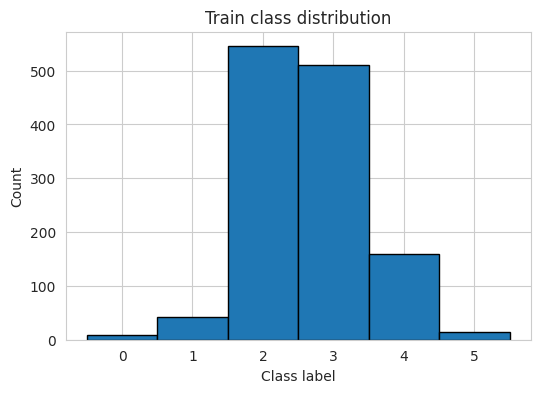

Classes: 6
Class weights: [2.2749309  0.99286124 0.27562268 0.2849234  0.51028716 1.66137462]


In [3]:
# TODO: Получите метки классов из train_dataset
# Hint: dm.train_dataset[i] возвращает (X, y)

train_labels = [dm.train_dataset[i][1].item() for i in range(len(dm.train_dataset))]

# TODO: Постройте гистограмму распределения классов
plt.figure(figsize=(6,4))
plt.hist(train_labels, bins=np.arange(min(train_labels)-0.5, max(train_labels)+1.5, 1), edgecolor='black')
plt.xlabel('Class label')
plt.ylabel('Count')
plt.title('Train class distribution')
plt.show()

# TODO: Вычислите веса классов используя compute_class_weight
n_classes = dm.n_classes


class_weights_balanced = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(n_classes),
    y=train_labels
)

alpha = 0.5
weights = class_weights_balanced ** alpha
class_weights = weights * (len(weights) / weights.sum())

print(f'Classes: {n_classes}')
print(f'Class weights: {class_weights}')

## 2. Реализация блоков

Реализуйте три типа блоков:
- **Bottleneck**: dim → dim//4 → dim (сужение)
- **Inverted Bottleneck**: dim → dim*4 → dim (расширение)
- **Regular**: dim → hidden_dim → dim (обычный)

In [4]:
from abc import ABC, abstractmethod

class BaseMLPBlock(nn.Module, ABC):
    """Базовый класс для MLP блока"""
    def __init__(self, dim, activation='gelu', dropout=0.0):
        super().__init__()
        self.dim = dim
        self.activation = {'relu': nn.ReLU(), 'gelu': nn.GELU(), 'swish': nn.SiLU()}.get(activation, nn.GELU())
        self.dropout = nn.Dropout(dropout) if dropout > 0 else None
    
    @abstractmethod
    def forward(self, x):
        pass

class BottleneckBlock(BaseMLPBlock):
    """
    Bottleneck блок: dim → dim//4 → dim
    
    Сужает размерность в 4 раза, затем восстанавливает.
    Использует residual connection для стабильного обучения.
    """
    def __init__(self, dim, activation='gelu', dropout=0.0):
        super().__init__(dim, activation, dropout)
        
        # Bottleneck dimension (сужение в 4 раза)
        self.bottleneck_dim = max(dim // 4, 1)
        
        # Линейные слои: dim → bottleneck_dim → dim
        self.fc1 = nn.Linear(self.dim, self.bottleneck_dim)
        self.fc2 = nn.Linear(self.bottleneck_dim, self.dim)
    
    def forward(self, x):
        identity = x
        
        # Bottleneck pathway
        out = self.fc1(x)
        out = self.activation(out)
        if self.dropout:
            out = self.dropout(out)
        out = self.fc2(out)
        
        # Residual connection
        return out + identity

class InvertedBottleneckBlock(BaseMLPBlock):
    """
    Inverted Bottleneck блок: dim → dim*4 → dim
    
    Расширяет размерность в 4 раза, затем сжимает обратно.
    Использует residual connection для стабильного обучения.
    """
    def __init__(self, dim, expansion_factor=4, activation='gelu', dropout=0.0):
        super().__init__(dim, activation, dropout)
        
        # Expanded dimension (расширение в 4 раза)
        self.expanded_dim = dim * expansion_factor
        
        # Линейные слои: dim → expanded_dim → dim
        self.fc1 = nn.Linear(self.dim, self.expanded_dim)
        self.fc2 = nn.Linear(self.expanded_dim, self.dim)
    
    def forward(self, x):
        identity = x
        
        # Inverted bottleneck pathway
        out = self.fc1(x)
        out = self.activation(out)
        if self.dropout:
            out = self.dropout(out)
        out = self.fc2(out)
        
        # Residual connection
        return out + identity

class RegularBlock(BaseMLPBlock):
    """
    Regular блок: dim → hidden_dim → dim
    
    Обычный двухслойный MLP с residual connection.
    hidden_dim по умолчанию равен dim * 2.
    """
    def __init__(self, dim, hidden_dim=None, activation='gelu', dropout=0.0):
        super().__init__(dim, activation, dropout)
        
        # Hidden dimension (по умолчанию в 2 раза больше)
        self.hidden_dim = hidden_dim if hidden_dim else dim * 2
        
        # Линейные слои: dim → hidden_dim → dim
        self.fc1 = nn.Linear(self.dim, self.hidden_dim)
        self.fc2 = nn.Linear(self.hidden_dim, self.dim)
    
    def forward(self, x):
        identity = x
        
        # Regular pathway
        out = self.fc1(x)
        out = self.activation(out)
        if self.dropout:
            out = self.dropout(out)
        out = self.fc2(out)
        
        # Residual connection
        return out + identity

# Тестируем блоки
print('✓ Блоки успешно определены!')
print()

# Проверим размерности
test_x = torch.randn(4, 64)
print('Тестирование блоков с размерностью 64:')
print(f'  Input shape: {test_x.shape}')

bottleneck = BottleneckBlock(64)
print(f'  BottleneckBlock output: {bottleneck(test_x).shape}')

inverted = InvertedBottleneckBlock(64)
print(f'  InvertedBottleneckBlock output: {inverted(test_x).shape}')

regular = RegularBlock(64)
print(f'  RegularBlock output: {regular(test_x).shape}')

# Подсчитаем параметры
print()
print('Количество параметров:')
print(f'  BottleneckBlock: {sum(p.numel() for p in bottleneck.parameters()):,}')
print(f'  InvertedBottleneckBlock: {sum(p.numel() for p in inverted.parameters()):,}')
print(f'  RegularBlock: {sum(p.numel() for p in regular.parameters()):,}')

✓ Блоки успешно определены!

Тестирование блоков с размерностью 64:
  Input shape: torch.Size([4, 64])
  BottleneckBlock output: torch.Size([4, 64])
  InvertedBottleneckBlock output: torch.Size([4, 64])
  RegularBlock output: torch.Size([4, 64])

Количество параметров:
  BottleneckBlock: 2,128
  InvertedBottleneckBlock: 33,088
  RegularBlock: 16,576


## 3. Multi-Branch модель

Реализуйте модель с тремя параллельными ветками.

**Архитектура**:
```
         Input
           |
      projection
           |
      ┌────┼────┐
      │    │    │
  Bottleneck  Inverted  Regular
   Branch      Branch    Branch
      │    │    │
      └────┼────┘
           |
      Concatenate/Sum
           |
      projection
           |
        Output
```

In [5]:
class MultiBranchMLP(nn.Module):
    """
    Multi-Branch MLP с тремя параллельными ветками.
    
    Args:
        input_dim: размерность входа
        hidden_dim: размерность скрытых слоев
        output_dim: размерность выхода (число классов)
        num_blocks: количество блоков в каждой ветке
        dropout: вероятность dropout
        combine_mode: способ объединения веток ('concat' или 'sum')
    """
    
    def __init__(
        self,
        input_dim,
        hidden_dim,
        output_dim,
        num_blocks=4,
        dropout=0.1,
        combine_mode='concat'
    ):
        super().__init__()
        self.output_dim = output_dim
        self.combine_mode = combine_mode

        # TODO: Входная проекция
        self.input_proj = nn.Linear(input_dim, hidden_dim)

        # TODO: Создайте три ветки (branches)
        # Branch 1: num_blocks блоков BottleneckBlock
        self.bottleneck_branch = nn.ModuleList(
            [BottleneckBlock(hidden_dim, dropout=dropout) for _ in range(num_blocks)]
        )
        
        # Branch 2: num_blocks блоков InvertedBottleneckBlock
        self.inverted_branch = nn.ModuleList(
            [InvertedBottleneckBlock(hidden_dim, dropout=dropout) for _ in range(num_blocks)]
        )
        
        # Branch 3: num_blocks блоков RegularBlock
        self.regular_branch = nn.ModuleList(
            [RegularBlock(hidden_dim, dropout=dropout) for _ in range(num_blocks)]
        )

        # TODO: Выходная проекция
        # Если combine_mode == 'concat', то вход будет hidden_dim * 3
        if self.combine_mode == 'concat':
            out_in_dim = hidden_dim * 3
        # Если combine_mode == 'sum', то вход будет hidden_dim
        elif self.combine_mode == 'sum':
            out_in_dim = hidden_dim
        else:
            raise ValueError(f'Unknown combine_mode: {self.combine_mode}')

        self.output_proj = nn.Sequential(
            nn.LayerNorm(out_in_dim),
            nn.Linear(out_in_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        # TODO: Реализуйте forward pass
        # 1. Входная проекция
        x = self.input_proj(x)

        # 2. Пропустите через каждую ветку
        b = x
        for block in self.bottleneck_branch:
            b = block(b)

        inv = x
        for block in self.inverted_branch:
            inv = block(inv)

        r = x
        for block in self.regular_branch:
            r = block(r)

       # 3. Объедините результаты (concat или sum)
        if self.combine_mode == 'concat':
            combined = torch.cat([b, inv, r], dim=-1)
        else:  # sum
            combined = b + inv + r

        # 4. Выходная проекция
        logits = self.output_proj(combined)
        return logits


## 4. Код обучение

In [6]:
def train_model(
    model,
    dm,
    class_weights=None,
    max_epochs=50,
    lr=1e-3,
    optimizer_type='adamw'
):
    """
    Обучает модель с weighted loss.
    
    Args:
        model: модель для обучения
        dm: DataModule
        class_weights: веса классов для weighted loss (numpy array или None)
        max_epochs: количество эпох
        lr: learning rate
        optimizer_type: тип оптимизатора ('adam', 'adamw', 'sgd')
    
    Returns:
        dict с метриками
        """
    
    # TODO: Создайте loss function
    # Если class_weights не None, используйте nn.CrossEntropyLoss(weight=torch.FloatTensor(class_weights))
    # Иначе используйте обычный nn.CrossEntropyLoss()
    
    if class_weights is not None:
        loss_fn = nn.CrossEntropyLoss(weight=torch.FloatTensor(class_weights))
    else:
        loss_fn = nn.CrossEntropyLoss()

    lightning_model = BaseLightningModule(
        model=model,
        loss_fn=loss_fn,
        optimizer_type=optimizer_type,
        learning_rate=lr,
        task_type='multiclass'
    )

    trainer = Trainer(
        max_epochs=max_epochs,
        enable_checkpointing=False,
        logger=False,
        enable_progress_bar=True,
        enable_model_summary=False
    )
    trainer.fit(lightning_model, dm)

    metrics = trainer.callback_metrics
    return {
        'val_acc': metrics.get('val_accuracy', 0).item(),
        'val_f1': metrics.get('val_f1_macro', 0).item()
    }


## 5. Подбор гиперпараметров

In [7]:
def find_best_hyperparameters(dm, class_weights, max_trials=15, max_epochs=50, patience=10):
    """
    Систематический поиск лучших гиперпараметров с использованием 
    стратегии "coarse-to-fine".
    
    Args:
        dm: DataModule
        class_weights: веса классов для weighted loss
        max_trials: максимальное количество экспериментов
        max_epochs: максимальное количество эпох
        patience: терпеливость для early stopping
    
    Returns:
        dict: лучшие гиперпараметры и метрики
    """
    import itertools
    from collections import defaultdict
    
    # Важные гиперпараметры для исследования (в порядке важности)
    param_grid = {
        'hidden_dim': [64, 128, 256],        # Наиболее важный параметр
        'num_blocks': [2, 4, 6],            # Второй по важности
        'lr': [1e-3, 5e-4, 1e-4],           # Learning rate
        'dropout': [0.0, 0.1, 0.2],         # Регуляризация
        'optimizer_type': ['adamw', 'adam', 'rmsprop'],  # Оптимизаторы
        'combine_mode': ['concat', 'sum']   # Способ объединения веток
    }
    
    # Приоритетный порядок исследования
    priority_order = [
        ('hidden_dim', 'num_blocks'),  # Начинаем с архитектуры
        ('lr', 'dropout'),             # Затем параметры обучения
        ('optimizer_type', 'combine_mode')  # Наконец, детали
    ]
    
    results = []
    best_f1 = 0.0
    best_params = None
    best_model = None
    
    # Счетчик экспериментов
    trial_count = 0
    
    print(f"Начинаем поиск гиперпараметров (макс. {max_trials} экспериментов)")
    print("-" * 60)
    
    # Фаза 1: Грубый поиск по ключевым параметрам
    print("Фаза 1: Грубый поиск по архитектуре")
    
    # Сначала тестируем базовые комбинации
    base_combinations = [
        {'hidden_dim': 128, 'num_blocks': 4, 'lr': 1e-3, 'dropout': 0.1, 
         'optimizer_type': 'adamw', 'combine_mode': 'concat'},
        {'hidden_dim': 256, 'num_blocks': 4, 'lr': 5e-4, 'dropout': 0.1,
         'optimizer_type': 'adamw', 'combine_mode': 'concat'},
        {'hidden_dim': 128, 'num_blocks': 6, 'lr': 1e-3, 'dropout': 0.2,
         'optimizer_type': 'adam', 'combine_mode': 'sum'},
    ]
    
    for params in base_combinations:
        if trial_count >= max_trials:
            break
            
        print(f"\nЭксперимент {trial_count + 1}: {params}")
        
        # Создаем модель
        model = MultiBranchMLP(
            input_dim=dm.input_dim,
            hidden_dim=params['hidden_dim'],
            output_dim=dm.n_classes,
            num_blocks=params['num_blocks'],
            dropout=params['dropout'],
            combine_mode=params['combine_mode']
        )
        
        # Обучаем с early stopping
        metrics = train_with_early_stopping(
            model=model,
            dm=dm,
            class_weights=class_weights,
            max_epochs=max_epochs,
            lr=params['lr'],
            optimizer_type=params['optimizer_type'],
            patience=patience
        )
        
        # Сохраняем результаты
        result = {
            'params': params.copy(),
            'val_f1': metrics['val_f1'],
            'val_acc': metrics['val_acc'],
            'epochs': metrics.get('epochs', max_epochs)
        }
        results.append(result)
        
        print(f"F1: {result['val_f1']:.4f}, Acc: {result['val_acc']:.4f}, Эпох: {result['epochs']}")
        
        # Обновляем лучший результат
        if result['val_f1'] > best_f1:
            best_f1 = result['val_f1']
            best_params = params.copy()
            best_model = model
            print(f" Новый лучший результат!")
        
        trial_count += 1
    
    # Фаза 2: Локальный поиск вокруг лучшего результата
    if best_f1 < 0.4 and trial_count < max_trials:
        print("\nФаза 2: Локальный поиск вокруг лучшего результата")
        
        # Создаем варианты на основе лучшего результата
        variations = []
        
        # Вариации по hidden_dim
        for hd in [best_params['hidden_dim'] // 2, best_params['hidden_dim'], 
                   min(best_params['hidden_dim'] * 2, 512)]:
            if hd != best_params['hidden_dim']:
                variation = best_params.copy()
                variation['hidden_dim'] = hd
                variations.append(variation)
        
        # Вариации по num_blocks
        for nb in [max(1, best_params['num_blocks'] - 1), best_params['num_blocks'], 
                   best_params['num_blocks'] + 1]:
            if nb != best_params['num_blocks']:
                variation = best_params.copy()
                variation['num_blocks'] = nb
                variations.append(variation)
        
        # Вариации по lr
        for lr in [best_params['lr'] * 2, best_params['lr'], best_params['lr'] / 2]:
            if lr != best_params['lr']:
                variation = best_params.copy()
                variation['lr'] = lr
                variations.append(variation)
        
        # Обучаем вариации
        for variation in variations[:max_trials - trial_count]:
            print(f"\nЭксперимент {trial_count + 1}: {variation}")
            
            model = MultiBranchMLP(
                input_dim=dm.input_dim,
                hidden_dim=variation['hidden_dim'],
                output_dim=dm.n_classes,
                num_blocks=variation['num_blocks'],
                dropout=variation['dropout'],
                combine_mode=variation['combine_mode']
            )
            
            metrics = train_with_early_stopping(
                model=model,
                dm=dm,
                class_weights=class_weights,
                max_epochs=max_epochs,
                lr=variation['lr'],
                optimizer_type=variation['optimizer_type'],
                patience=patience
            )
            
            result = {
                'params': variation.copy(),
                'val_f1': metrics['val_f1'],
                'val_acc': metrics['val_acc'],
                'epochs': metrics.get('epochs', max_epochs)
            }
            results.append(result)
            
            print(f"  F1: {result['val_f1']:.4f}, Acc: {result['val_acc']:.4f}, Эпох: {result['epochs']}")
            
            if result['val_f1'] > best_f1:
                best_f1 = result['val_f1']
                best_params = variation.copy()
                best_model = model
                print(f"Новый лучший результат!")
            
            trial_count += 1
    
    # Фаза 3: Тонкая настройка dropout и других параметров
    if best_f1 < 0.4 and trial_count < max_trials:
        print("\nФаза 3: Тонкая настройка регуляризации")
        
        # Тестируем разные dropout
        for dropout in [0.0, 0.05, 0.1, 0.15, 0.2, 0.3]:
            if trial_count >= max_trials:
                break
                
            if dropout != best_params['dropout']:
                variation = best_params.copy()
                variation['dropout'] = dropout
                
                print(f"\nЭксперимент {trial_count + 1}: {variation}")
                
                model = MultiBranchMLP(
                    input_dim=dm.input_dim,
                    hidden_dim=variation['hidden_dim'],
                    output_dim=dm.n_classes,
                    num_blocks=variation['num_blocks'],
                    dropout=variation['dropout'],
                    combine_mode=variation['combine_mode']
                )
                
                metrics = train_with_early_stopping(
                    model=model,
                    dm=dm,
                    class_weights=class_weights,
                    max_epochs=max_epochs,
                    lr=variation['lr'],
                    optimizer_type=variation['optimizer_type'],
                    patience=patience
                )
                
                result = {
                    'params': variation.copy(),
                    'val_f1': metrics['val_f1'],
                    'val_acc': metrics['val_acc'],
                    'epochs': metrics.get('epochs', max_epochs)
                }
                results.append(result)
                
                print(f"  F1: {result['val_f1']:.4f}, Acc: {result['val_acc']:.4f}, Эпох: {result['epochs']}")
                
                if result['val_f1'] > best_f1:
                    best_f1 = result['val_f1']
                    best_params = variation.copy()
                    best_model = model
                    print(f"Новый лучший результат!")
                
                trial_count += 1
    
    # Вывод итогов
    print("\n" + "=" * 60)
    print("РЕЗУЛЬТАТЫ ПОИСКА ГИПЕРПАРАМЕТРОВ")
    print("=" * 60)
    
    # Сортируем результаты по F1-score
    results.sort(key=lambda x: x['val_f1'], reverse=True)
    
    print(f"\nЛучший результат: F1 = {best_f1:.4f}")
    print("Лучшие параметры:")
    for key, value in best_params.items():
        print(f"  {key}: {value}")
    
    print(f"\nТоп-5 результатов:")
    for i, res in enumerate(results[:5]):
        print(f"{i+1}. F1: {res['val_f1']:.4f}, Acc: {res['val_acc']:.4f}")
        print(f"   Параметры: {res['params']}")
        print()
    
    return {
        'best_params': best_params,
        'best_f1': best_f1,
        'best_model': best_model,
        'all_results': results
    }


def train_with_early_stopping(model, dm, class_weights=None, max_epochs=50, 
                              lr=1e-3, optimizer_type='adamw', patience=5):
    """
    Обучает модель с ранней остановкой.
    
    Args:
        model: модель для обучения
        dm: DataModule
        class_weights: веса классов
        max_epochs: максимальное количество эпох
        lr: learning rate
        optimizer_type: тип оптимизатора
        patience: количество эпох без улучшения для остановки
    
    Returns:
        dict с метриками и количеством эпох
    """
    from pytorch_lightning.callbacks import EarlyStopping
    
    # Создаем loss function
    if class_weights is not None:
        loss_fn = nn.CrossEntropyLoss(weight=torch.FloatTensor(class_weights))
    else:
        loss_fn = nn.CrossEntropyLoss()
    
    # Создаем lightning модель
    lightning_model = BaseLightningModule(
        model=model,
        loss_fn=loss_fn,
        optimizer_type=optimizer_type,
        learning_rate=lr,
        task_type='multiclass'
    )
    
    # Callback для ранней остановки
    early_stop_callback = EarlyStopping(
        monitor='val_f1_macro',
        min_delta=0.001,
        patience=patience,
        verbose=False,
        mode='max'
    )
    
    # Создаем trainer
    trainer = Trainer(
        max_epochs=max_epochs,
        callbacks=[early_stop_callback],
        enable_checkpointing=False,
        logger=False,
        enable_progress_bar=False,  # Отключаем для чистоты вывода
        enable_model_summary=False
    )
    
    # Обучаем модель
    trainer.fit(lightning_model, dm)
    
    # Получаем метрики
    metrics = trainer.callback_metrics
    
    return {
        'val_acc': metrics.get('val_accuracy', 0).item(),
        'val_f1': metrics.get('val_f1_macro', 0).item(),
        'epochs': trainer.current_epoch
    }

In [8]:
# Используем вычисленные веса классов
best_results = find_best_hyperparameters(
    dm=dm,
    class_weights=class_weights,
    max_trials=50,  # Ограничиваем количество экспериментов
    max_epochs=200,
    patience=7
)

# Получаем лучшую модель
best_model = best_results['best_model']
print(f"Лучший F1-score: {best_results['best_f1']:.4f}")

Начинаем поиск гиперпараметров (макс. 50 экспериментов)
------------------------------------------------------------
Фаза 1: Грубый поиск по архитектуре

Эксперимент 1: {'hidden_dim': 128, 'num_blocks': 4, 'lr': 0.001, 'dropout': 0.1, 'optimizer_type': 'adamw', 'combine_mode': 'concat'}


GPU available: False, used: False
TPU available: False, using: 0 TPU cores


Epoch 0: accuracy=0.0781, f1_macro=0.0875
Epoch 0: accuracy=0.3420, f1_macro=0.2590
Epoch 1: accuracy=0.4252, f1_macro=0.2970
Epoch 2: accuracy=0.4622, f1_macro=0.3053
Epoch 3: accuracy=0.4870, f1_macro=0.3152
Epoch 4: accuracy=0.4989, f1_macro=0.3176
Epoch 5: accuracy=0.5078, f1_macro=0.3170
Epoch 6: accuracy=0.5076, f1_macro=0.3157
Epoch 7: accuracy=0.5192, f1_macro=0.3198
Epoch 8: accuracy=0.5236, f1_macro=0.3203
Epoch 9: accuracy=0.5266, f1_macro=0.3198
Epoch 10: accuracy=0.5328, f1_macro=0.3228
Epoch 11: accuracy=0.5354, f1_macro=0.3214
Epoch 12: accuracy=0.5383, f1_macro=0.3228
Epoch 13: accuracy=0.5412, f1_macro=0.3245
Epoch 14: accuracy=0.5445, f1_macro=0.3258
Epoch 15: accuracy=0.5478, f1_macro=0.3264
Epoch 16: accuracy=0.5493, f1_macro=0.3279
Epoch 17: accuracy=0.5519, f1_macro=0.3290
Epoch 18: accuracy=0.5527, f1_macro=0.3310
Epoch 19: accuracy=0.5553, f1_macro=0.3329
Epoch 20: accuracy=0.5563, f1_macro=0.3318
Epoch 21: accuracy=0.5583, f1_macro=0.3323
Epoch 22: accuracy=0.5

GPU available: False, used: False
TPU available: False, using: 0 TPU cores


Epoch 0: accuracy=0.1445, f1_macro=0.1046
Epoch 0: accuracy=0.3628, f1_macro=0.2175
Epoch 1: accuracy=0.4163, f1_macro=0.2442
Epoch 2: accuracy=0.4688, f1_macro=0.2695
Epoch 3: accuracy=0.4928, f1_macro=0.2815
Epoch 4: accuracy=0.5032, f1_macro=0.2906
Epoch 5: accuracy=0.5097, f1_macro=0.2911
Epoch 6: accuracy=0.5180, f1_macro=0.2951
Epoch 7: accuracy=0.5220, f1_macro=0.2967
Epoch 8: accuracy=0.5293, f1_macro=0.2983
Epoch 9: accuracy=0.5312, f1_macro=0.2985
Epoch 10: accuracy=0.5360, f1_macro=0.3005
Epoch 11: accuracy=0.5403, f1_macro=0.3024
Epoch 12: accuracy=0.5455, f1_macro=0.3050
Epoch 13: accuracy=0.5496, f1_macro=0.3086
Epoch 14: accuracy=0.5532, f1_macro=0.3126
Epoch 15: accuracy=0.5562, f1_macro=0.3144
Epoch 16: accuracy=0.5604, f1_macro=0.3186
Epoch 17: accuracy=0.5628, f1_macro=0.3218
Epoch 18: accuracy=0.5649, f1_macro=0.3242
Epoch 19: accuracy=0.5676, f1_macro=0.3258
Epoch 20: accuracy=0.5701, f1_macro=0.3280
Epoch 21: accuracy=0.5720, f1_macro=0.3294
Epoch 22: accuracy=0.5

...

Epoch 0: accuracy=0.1133, f1_macro=0.0979
Epoch 0: accuracy=0.3785, f1_macro=0.2325
Epoch 1: accuracy=0.4498, f1_macro=0.2720
Epoch 2: accuracy=0.4811, f1_macro=0.2897
Epoch 3: accuracy=0.5072, f1_macro=0.3016
Epoch 4: accuracy=0.5216, f1_macro=0.3044
Epoch 5: accuracy=0.5244, f1_macro=0.3090
Epoch 6: accuracy=0.5361, f1_macro=0.3160
Epoch 7: accuracy=0.5391, f1_macro=0.3174
Epoch 8: accuracy=0.5437, f1_macro=0.3189
Epoch 9: accuracy=0.5437, f1_macro=0.3195
Epoch 10: accuracy=0.5511, f1_macro=0.3224
Epoch 11: accuracy=0.5520, f1_macro=0.3230
Epoch 12: accuracy=0.5566, f1_macro=0.3274
Epoch 13: accuracy=0.5593, f1_macro=0.3289
Epoch 14: accuracy=0.5619, f1_macro=0.3304
Epoch 15: accuracy=0.5653, f1_macro=0.3311
Epoch 16: accuracy=0.5678, f1_macro=0.3315
Epoch 17: accuracy=0.5695, f1_macro=0.3329
Epoch 18: accuracy=0.5721, f1_macro=0.3351
Epoch 19: accuracy=0.5745, f1_macro=0.3360
Epoch 20: accuracy=0.5770, f1_macro=0.3371
Epoch 21: accuracy=0.5783, f1_macro=0.3390
Epoch 22: accuracy=0.5

GPU available: False, used: False
TPU available: False, using: 0 TPU cores


Epoch 0: accuracy=0.2305, f1_macro=0.1255
Epoch 0: accuracy=0.4028, f1_macro=0.2175
Epoch 1: accuracy=0.4554, f1_macro=0.2405
Epoch 2: accuracy=0.4811, f1_macro=0.2600
Epoch 3: accuracy=0.5065, f1_macro=0.2765
Epoch 4: accuracy=0.5194, f1_macro=0.2833
Epoch 5: accuracy=0.5262, f1_macro=0.2877
Epoch 6: accuracy=0.5345, f1_macro=0.2942
Epoch 7: accuracy=0.5387, f1_macro=0.2978
Epoch 8: accuracy=0.5408, f1_macro=0.2999
Epoch 9: accuracy=0.5420, f1_macro=0.3024
Epoch 10: accuracy=0.5434, f1_macro=0.3034
Epoch 11: accuracy=0.5481, f1_macro=0.3064
Epoch 12: accuracy=0.5507, f1_macro=0.3082
Epoch 13: accuracy=0.5526, f1_macro=0.3087
Epoch 14: accuracy=0.5570, f1_macro=0.3117
Epoch 15: accuracy=0.5592, f1_macro=0.3134
Epoch 16: accuracy=0.5611, f1_macro=0.3142
Epoch 17: accuracy=0.5622, f1_macro=0.3151
Epoch 18: accuracy=0.5627, f1_macro=0.3175
Epoch 19: accuracy=0.5646, f1_macro=0.3211
Epoch 20: accuracy=0.5678, f1_macro=0.3241
Epoch 21: accuracy=0.5678, f1_macro=0.3254
Epoch 22: accuracy=0.5

GPU available: False, used: False
TPU available: False, using: 0 TPU cores


Epoch 0: accuracy=0.1914, f1_macro=0.1032
Epoch 0: accuracy=0.3819, f1_macro=0.2353
Epoch 1: accuracy=0.4598, f1_macro=0.2590
Epoch 2: accuracy=0.4951, f1_macro=0.2827
Epoch 3: accuracy=0.5163, f1_macro=0.2999
Epoch 4: accuracy=0.5275, f1_macro=0.3064
Epoch 5: accuracy=0.5345, f1_macro=0.3093
Epoch 6: accuracy=0.5369, f1_macro=0.3134
Epoch 7: accuracy=0.5447, f1_macro=0.3154
Epoch 8: accuracy=0.5469, f1_macro=0.3144
Epoch 9: accuracy=0.5501, f1_macro=0.3167
Epoch 10: accuracy=0.5524, f1_macro=0.3155
Epoch 11: accuracy=0.5532, f1_macro=0.3157
Epoch 12: accuracy=0.5575, f1_macro=0.3178
Epoch 13: accuracy=0.5583, f1_macro=0.3190
Epoch 14: accuracy=0.5623, f1_macro=0.3196
Epoch 15: accuracy=0.5629, f1_macro=0.3200
Epoch 16: accuracy=0.5644, f1_macro=0.3211
Epoch 17: accuracy=0.5663, f1_macro=0.3206
Epoch 18: accuracy=0.5680, f1_macro=0.3216
Epoch 19: accuracy=0.5693, f1_macro=0.3240
Epoch 20: accuracy=0.5710, f1_macro=0.3256
Epoch 21: accuracy=0.5722, f1_macro=0.3265
Epoch 22: accuracy=0.5

## 6. Итоговая модель

Обучите модель с лучшими гиперпараметрами.

In [9]:
# Обучаем итоговую модель с лучшими гиперпараметрами

final_model = MultiBranchMLP(
    input_dim=dm.input_dim,
    hidden_dim=best_results['best_params'].get('hidden_dim', 256),
    output_dim=dm.n_classes,
    num_blocks=best_results['best_params'].get('num_blocks', 6),
    dropout=best_results['best_params'].get('dropout', 0.1),
    combine_mode=best_results['best_params'].get('combine_mode', 'concat')
)

final_results = train_model(
    final_model,
    dm,
    class_weights=class_weights,
    max_epochs=200,
    lr=best_results['best_params'].get('lr', 1e-3),
    optimizer_type=best_results['best_params'].get('optimizer_type', 'adamw'),
)

print(f'\n=== Итоговые результаты ===')
print(f"F1 score: {final_results['val_f1']:.4f}")
print(f"Accuracy: {final_results['val_acc']:.4f}")

GPU available: False, used: False
TPU available: False, using: 0 TPU cores


Output()

Epoch 0: accuracy=0.3086, f1_macro=0.1331

Epoch 0: accuracy=0.4479, f1_macro=0.2345

Epoch 1: accuracy=0.4833, f1_macro=0.2641

...

Epoch 197: accuracy=0.6085, f1_macro=0.3658

Epoch 198: accuracy=0.6086, f1_macro=0.3659

Epoch 199: accuracy=0.6088, f1_macro=0.3661

`Trainer.fit` stopped: `max_epochs=200` reached.



=== Итоговые результаты ===
F1 score: 0.3661
Accuracy: 0.6088
